In [1]:
import seaborn as sns 
import pandas as pd 
import matplotlib.pyplot as plt 

/home/haz19024/.venv/work/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# df = pd.read_csv('./experiments.csv')
df = pd.read_csv('./experiments.csv.2')
# df = pd.read_csv('./experiments_best_threshold.csv')
# df = pd.read_csv('./experiments_swtich_a.csv')
# df = pd.read_csv('./experiments_swtich_y.csv')
# df = pd.read_csv('./experiments_swtich_a_y.csv')

In [3]:
def lighten_color(color, amount=0.5):
    """
    Lightens the given color by multiplying (1-luminosity) by the given amount.
    Input can be matplotlib color string, hex string, or RGB tuple.

    Examples:
    >> lighten_color('g', 0.3)
    >> lighten_color('#F034A3', 0.6)
    >> lighten_color((.3,.55,.1), 0.5)
    """
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])

[<matplotlib.patches.Rectangle object at 0x76c952012ce0>, <matplotlib.patches.Rectangle object at 0x76c952012c20>] ['eta', 'gemma']


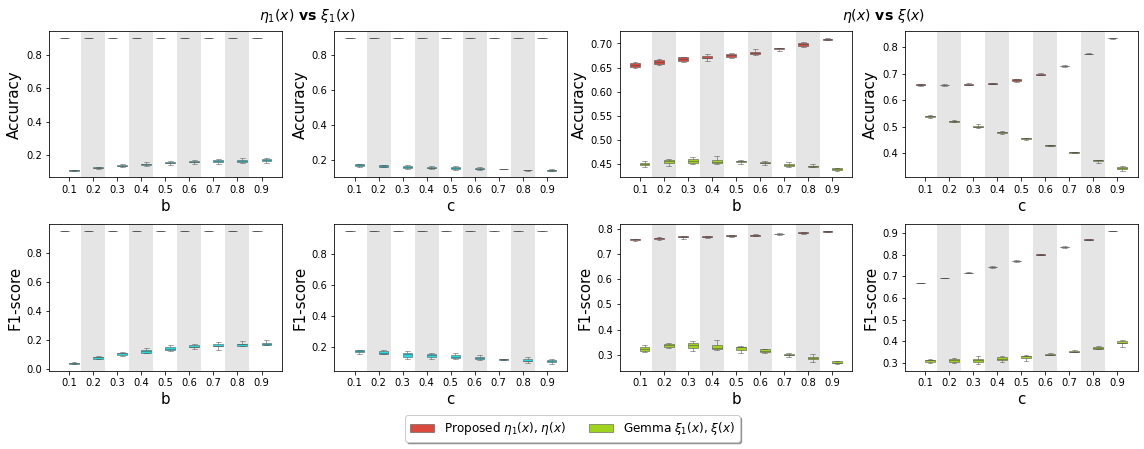

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 6))

a = 0.5
metrics_name_map = {'F-0.5': 'F-0.5 Score', 'F': 'F-1 Score', 'F-2': 'F-2 Score', 'ACC': 'Accuracy'}
palette = sns.color_palette('Paired')
# c1 = [palette[3], palette[2]]
# c2 = [palette[7], palette[6]]
cc = [lighten_color('#F8766D', amount=1.5), lighten_color('#00BFC4', amount=0.8)]
cc2 = [lighten_color('#F8766D', amount=1.5), lighten_color('#7CAE00', amount=0.8)]

sns.boxplot(ax=axes[1][0], data=df[(df['a']==a) & (df['c']==0.5) & (df['model'].isin(['eta1', 'eta1_bench'])) & (df['metric']=='F')], x='b', y='value', hue='model', palette=cc, showfliers=False, linewidth=0.5)
sns.boxplot(ax=axes[1][1], data=df[(df['a']==a) & (df['b']==0.5) &(df['model'].isin(['eta1', 'eta1_bench'])) & (df['metric']=='F')], x='c', y='value', hue='model', palette=cc, showfliers=False, linewidth=0.5)
sns.boxplot(ax=axes[0][0], data=df[(df['a']==a) & (df['c']==0.5) &(df['model'].isin(['eta1', 'eta1_bench'])) & (df['metric']=='ACC')], x='b', y='value', hue='model', palette=cc, showfliers=False, linewidth=0.5)
sns.boxplot(ax=axes[0][1], data=df[(df['a']==a) & (df['b']==0.5) &(df['model'].isin(['eta1', 'eta1_bench'])) & (df['metric']=='ACC')], x='c', y='value', hue='model', palette=cc, showfliers=False, linewidth=0.5)
sns.boxplot(ax=axes[1][2], data=df[(df['a']==a) & (df['c']==0.5) &(df['model'].isin(['eta', 'gemma'])) & (df['metric']=='F')], x='b', y='value', hue='model', palette=cc2, showfliers=False, linewidth=0.5)
sns.boxplot(ax=axes[1][3], data=df[(df['a']==a) & (df['b']==0.5) &(df['model'].isin(['eta', 'gemma'])) & (df['metric']=='F')], x='c', y='value', hue='model', palette=cc2, showfliers=False, linewidth=0.5)
sns.boxplot(ax=axes[0][2], data=df[(df['a']==a) & (df['c']==0.5) &(df['model'].isin(['eta', 'gemma'])) & (df['metric']=='ACC')], x='b', y='value', hue='model', palette=cc2, showfliers=False, linewidth=0.5)
sns.boxplot(ax=axes[0][3], data=df[(df['a']==a) & (df['b']==0.5) &(df['model'].isin(['eta', 'gemma'])) & (df['metric']=='ACC')], x='c', y='value', hue='model', palette=cc2, showfliers=False, linewidth=0.5)
axes[1][0].set_ylabel('F1-score', fontsize=15)
axes[1][1].set_ylabel('F1-score', fontsize=15)
axes[1][2].set_ylabel('F1-score', fontsize=15)
axes[1][3].set_ylabel('F1-score', fontsize=15)
axes[0][0].set_ylabel('Accuracy', fontsize=15)
axes[0][1].set_ylabel('Accuracy',fontsize=15)
axes[0][2].set_ylabel('Accuracy',fontsize=15)
axes[0][3].set_ylabel('Accuracy',fontsize=15)
axes[0][0].set_xlabel(f'b', fontsize=15)
axes[0][1].set_xlabel(f'c',fontsize=15)
axes[1][0].set_xlabel(f'b', fontsize=15)
axes[1][1].set_xlabel(f'c',fontsize=15 )
axes[0][2].set_xlabel(f'b',fontsize=15)
axes[0][3].set_xlabel(f'c',fontsize=15)
axes[1][2].set_xlabel(f'b', fontsize=15)
axes[1][3].set_xlabel(f'c',fontsize=15)
# axes[0][0].set_ylim((0.48, 0.89))
# axes[0][1].set_ylim((0.48, 0.89))
# axes[0][2].set_ylim((0.48, 0.89))
# axes[0][3].set_ylim((0.48, 0.89))

# axes[1][0].set_ylim((0.17, 0.85))
# axes[1][1].set_ylim((0.17, 0.85))
# axes[1][2].set_ylim((0.17, 0.85))
# axes[1][3].set_ylim((0.17, 0.85))
for i in range(2):
    for j in range(4):
        axes[i][j].legend_.remove()
        for k in range(0, 8):
            if k % 2 == 1:
                axes[i][j].axvspan(k-.5, k+.5, facecolor='black', alpha=0.1)
handles, labels = axes[0][2].get_legend_handles_labels()
print(handles, labels)
# handles2, labels2 = axes[0][3].get_legend_handles_labels()
# handles = handles1 + handles2

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.07),
          fancybox=True, shadow=True, ncol=5, handles=handles, labels=[r'Proposed $\eta_1(x)$, $\eta(x)$', r'Gemma $\xi_1(x)$, $\xi(x)$'], fontsize=12)

fig.text(0.27, 0.92, r'$\eta_1(x)$ vs $\xi_1(x)$', ha='center', fontsize=14, weight='bold')
fig.text(0.77, 0.92, r'$\eta(x)$ vs $\xi(x)$', ha='center', fontsize=14, weight='bold')

# Optional: Adjust spacing
plt.subplots_adjust(top=0.90, hspace=0.4)
fig.tight_layout(rect=[0, 0, 1, 0.92]) 


[<matplotlib.patches.Rectangle object at 0x76c951101060>, <matplotlib.patches.Rectangle object at 0x76c951101570>, <matplotlib.patches.Rectangle object at 0x76c951101600>] ['eta', 'eta_bench', 'gemma']


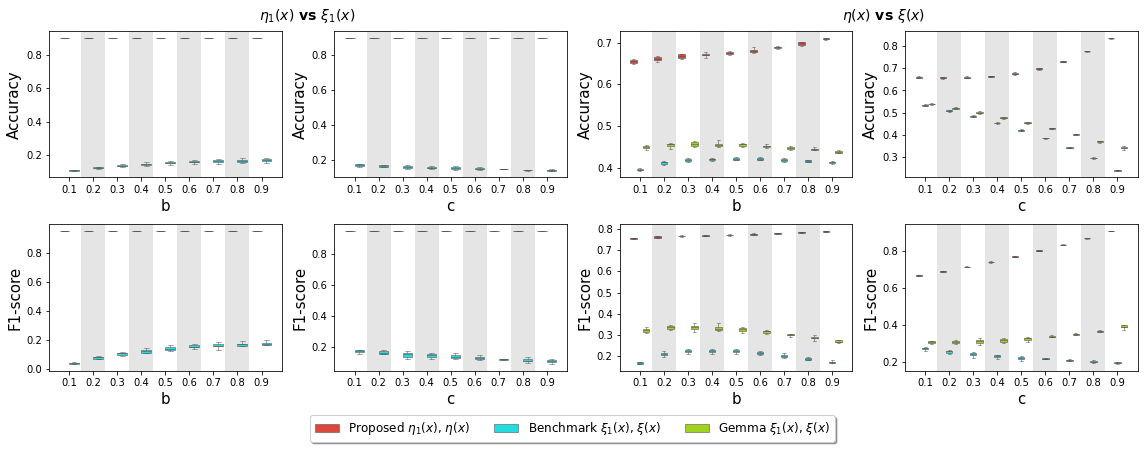

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 6))

a = 0.5
metrics_name_map = {'F-0.5': 'F-0.5 Score', 'F': 'F-1 Score', 'F-2': 'F-2 Score', 'ACC': 'Accuracy'}
palette = sns.color_palette('Paired')
# c1 = [palette[3], palette[2]]
# c2 = [palette[7], palette[6]]
cc = [lighten_color('#F8766D', amount=1.5), lighten_color('#00BFC4', amount=0.8)]
cc2 = [lighten_color('#F8766D', amount=1.5), lighten_color('#00BFC4', amount=0.8), lighten_color('#7CAE00', amount=0.8)]

sns.boxplot(ax=axes[1][0], data=df[(df['a']==a) & (df['c']==0.5) & (df['model'].isin(['eta1', 'eta1_bench'])) & (df['metric']=='F')], x='b', y='value', hue='model', palette=cc, showfliers=False, linewidth=0.5)
sns.boxplot(ax=axes[1][1], data=df[(df['a']==a) & (df['b']==0.5) &(df['model'].isin(['eta1', 'eta1_bench'])) & (df['metric']=='F')], x='c', y='value', hue='model', palette=cc, showfliers=False, linewidth=0.5)
sns.boxplot(ax=axes[0][0], data=df[(df['a']==a) & (df['c']==0.5) &(df['model'].isin(['eta1', 'eta1_bench'])) & (df['metric']=='ACC')], x='b', y='value', hue='model', palette=cc, showfliers=False, linewidth=0.5)
sns.boxplot(ax=axes[0][1], data=df[(df['a']==a) & (df['b']==0.5) &(df['model'].isin(['eta1', 'eta1_bench'])) & (df['metric']=='ACC')], x='c', y='value', hue='model', palette=cc, showfliers=False, linewidth=0.5)
sns.boxplot(ax=axes[1][2], data=df[(df['a']==a) & (df['c']==0.5) &(df['model'].isin(['eta', 'eta_bench', 'gemma'])) & (df['metric']=='F')], x='b', y='value', hue='model', palette=cc2, hue_order=['eta', 'eta_bench', 'gemma'] ,showfliers=False, linewidth=0.5)
sns.boxplot(ax=axes[1][3], data=df[(df['a']==a) & (df['b']==0.5) &(df['model'].isin(['eta', 'eta_bench', 'gemma'])) & (df['metric']=='F')], x='c', y='value', hue='model', palette=cc2, showfliers=False, linewidth=0.5)
sns.boxplot(ax=axes[0][2], data=df[(df['a']==a) & (df['c']==0.5) &(df['model'].isin(['eta', 'eta_bench', 'gemma'])) & (df['metric']=='ACC')], x='b', y='value', hue='model', palette=cc2, showfliers=False, linewidth=0.5)
sns.boxplot(ax=axes[0][3], data=df[(df['a']==a) & (df['b']==0.5) &(df['model'].isin(['eta', 'eta_bench', 'gemma'])) & (df['metric']=='ACC')], x='c', y='value', hue='model', palette=cc2, showfliers=False, linewidth=0.5)
axes[1][0].set_ylabel('F1-score', fontsize=15)
axes[1][1].set_ylabel('F1-score', fontsize=15)
axes[1][2].set_ylabel('F1-score', fontsize=15)
axes[1][3].set_ylabel('F1-score', fontsize=15)
axes[0][0].set_ylabel('Accuracy', fontsize=15)
axes[0][1].set_ylabel('Accuracy',fontsize=15)
axes[0][2].set_ylabel('Accuracy',fontsize=15)
axes[0][3].set_ylabel('Accuracy',fontsize=15)
axes[0][0].set_xlabel(f'b', fontsize=15)
axes[0][1].set_xlabel(f'c',fontsize=15)
axes[1][0].set_xlabel(f'b', fontsize=15)
axes[1][1].set_xlabel(f'c',fontsize=15 )
axes[0][2].set_xlabel(f'b',fontsize=15)
axes[0][3].set_xlabel(f'c',fontsize=15)
axes[1][2].set_xlabel(f'b', fontsize=15)
axes[1][3].set_xlabel(f'c',fontsize=15)
# axes[0][0].set_ylim((0.48, 0.89))
# axes[0][1].set_ylim((0.48, 0.89))
# axes[0][2].set_ylim((0.48, 0.89))
# axes[0][3].set_ylim((0.48, 0.89))

# axes[1][0].set_ylim((0.17, 0.85))
# axes[1][1].set_ylim((0.17, 0.85))
# axes[1][2].set_ylim((0.17, 0.85))
# axes[1][3].set_ylim((0.17, 0.85))
for i in range(2):
    for j in range(4):
        axes[i][j].legend_.remove()
        for k in range(0, 8):
            if k % 2 == 1:
                axes[i][j].axvspan(k-.5, k+.5, facecolor='black', alpha=0.1)
handles, labels = axes[0][2].get_legend_handles_labels()
print(handles, labels)
# handles2, labels2 = axes[0][3].get_legend_handles_labels()
# handles = handles1 + handles2

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.07),
          fancybox=True, shadow=True, ncol=5, handles=handles, labels=[r'Proposed $\eta_1(x)$, $\eta(x)$',  r'Benchmark $\xi_1(x)$, $\xi(x)$', r'Gemma $\xi_1(x)$, $\xi(x)$'], fontsize=12)

fig.text(0.27, 0.92, r'$\eta_1(x)$ vs $\xi_1(x)$', ha='center', fontsize=14, weight='bold')
fig.text(0.77, 0.92, r'$\eta(x)$ vs $\xi(x)$', ha='center', fontsize=14, weight='bold')

# Optional: Adjust spacing
plt.subplots_adjust(top=0.90, hspace=0.4)
fig.tight_layout(rect=[0, 0, 1, 0.92]) 


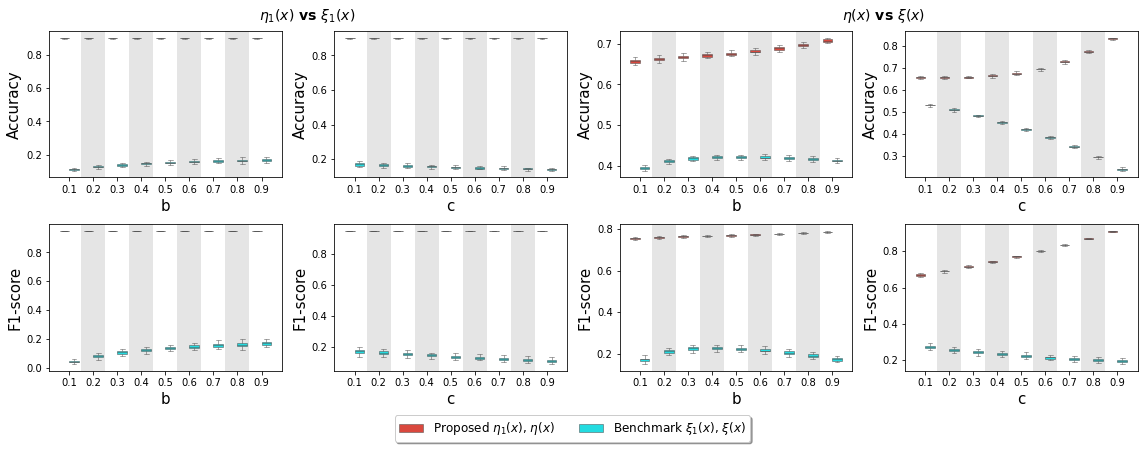

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 6))

a = 0.5
metrics_name_map = {'F-0.5': 'F-0.5 Score', 'F': 'F-1 Score', 'F-2': 'F-2 Score', 'ACC': 'Accuracy'}
palette = sns.color_palette('Paired')
# c1 = [palette[3], palette[2]]
# c2 = [palette[7], palette[6]]
cc = [lighten_color('#F8766D', amount=1.5), lighten_color('#00BFC4', amount=0.8)]

sns.boxplot(ax=axes[1][0], data=df[(df['a']==a) & (df['c']==0.5) & (df['model'].isin(['eta1', 'eta1_bench'])) & (df['metric']=='F')], x='b', y='value', hue='model', palette=cc, showfliers=False, linewidth=0.5)
sns.boxplot(ax=axes[1][1], data=df[(df['a']==a) & (df['b']==0.5) &(df['model'].isin(['eta1', 'eta1_bench'])) & (df['metric']=='F')], x='c', y='value', hue='model', palette=cc, showfliers=False, linewidth=0.5)
sns.boxplot(ax=axes[0][0], data=df[(df['a']==a) & (df['c']==0.5) &(df['model'].isin(['eta1', 'eta1_bench'])) & (df['metric']=='ACC')], x='b', y='value', hue='model', palette=cc, showfliers=False, linewidth=0.5)
sns.boxplot(ax=axes[0][1], data=df[(df['a']==a) & (df['b']==0.5) &(df['model'].isin(['eta1', 'eta1_bench'])) & (df['metric']=='ACC')], x='c', y='value', hue='model', palette=cc, showfliers=False, linewidth=0.5)
sns.boxplot(ax=axes[1][2], data=df[(df['a']==a) & (df['c']==0.5) &(df['model'].isin(['eta', 'eta_bench'])) & (df['metric']=='F')], x='b', y='value', hue='model', palette=cc, showfliers=False, linewidth=0.5)
sns.boxplot(ax=axes[1][3], data=df[(df['a']==a) & (df['b']==0.5) &(df['model'].isin(['eta', 'eta_bench'])) & (df['metric']=='F')], x='c', y='value', hue='model', palette=cc, showfliers=False, linewidth=0.5)
sns.boxplot(ax=axes[0][2], data=df[(df['a']==a) & (df['c']==0.5) &(df['model'].isin(['eta', 'eta_bench'])) & (df['metric']=='ACC')], x='b', y='value', hue='model', palette=cc, showfliers=False, linewidth=0.5)
sns.boxplot(ax=axes[0][3], data=df[(df['a']==a) & (df['b']==0.5) &(df['model'].isin(['eta', 'eta_bench'])) & (df['metric']=='ACC')], x='c', y='value', hue='model', palette=cc, showfliers=False, linewidth=0.5)
axes[1][0].set_ylabel('F1-score', fontsize=15)
axes[1][1].set_ylabel('F1-score', fontsize=15)
axes[1][2].set_ylabel('F1-score', fontsize=15)
axes[1][3].set_ylabel('F1-score', fontsize=15)
axes[0][0].set_ylabel('Accuracy', fontsize=15)
axes[0][1].set_ylabel('Accuracy',fontsize=15)
axes[0][2].set_ylabel('Accuracy',fontsize=15)
axes[0][3].set_ylabel('Accuracy',fontsize=15)
axes[0][0].set_xlabel(f'b', fontsize=15)
axes[0][1].set_xlabel(f'c',fontsize=15)
axes[1][0].set_xlabel(f'b', fontsize=15)
axes[1][1].set_xlabel(f'c',fontsize=15 )
axes[0][2].set_xlabel(f'b',fontsize=15)
axes[0][3].set_xlabel(f'c',fontsize=15)
axes[1][2].set_xlabel(f'b', fontsize=15)
axes[1][3].set_xlabel(f'c',fontsize=15)
# axes[0][0].set_ylim((0.48, 0.89))
# axes[0][1].set_ylim((0.48, 0.89))
# axes[0][2].set_ylim((0.48, 0.89))
# axes[0][3].set_ylim((0.48, 0.89))

# axes[1][0].set_ylim((0.17, 0.85))
# axes[1][1].set_ylim((0.17, 0.85))
# axes[1][2].set_ylim((0.17, 0.85))
# axes[1][3].set_ylim((0.17, 0.85))
for i in range(2):
    for j in range(4):
        axes[i][j].legend_.remove()
        for k in range(0, 8):
            if k % 2 == 1:
                axes[i][j].axvspan(k-.5, k+.5, facecolor='black', alpha=0.1)
handles, labels = axes[0][0].get_legend_handles_labels()
# handles2, labels2 = axes[0][3].get_legend_handles_labels()
# handles = handles1 + handles2

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.07),
          fancybox=True, shadow=True, ncol=5, handles=handles, labels=[r'Proposed $\eta_1(x)$, $\eta(x)$',  r'Benchmark $\xi_1(x)$, $\xi(x)$'], fontsize=12)

fig.text(0.27, 0.92, r'$\eta_1(x)$ vs $\xi_1(x)$', ha='center', fontsize=14, weight='bold')
fig.text(0.77, 0.92, r'$\eta(x)$ vs $\xi(x)$', ha='center', fontsize=14, weight='bold')

# Optional: Adjust spacing
plt.subplots_adjust(top=0.90, hspace=0.4)
fig.tight_layout(rect=[0, 0, 1, 0.92]) 
# plt.tight_layout()
# plt.savefig(f'eta_a_{a}.svg', bbox_inches = 'tight', format='svg')
# plt.savefig(f'eta_a_{a}.pdf', bbox_inches = 'tight', format='pdf', dpi=500)
plt.savefig(f'eta1_eta_a_{a}_celeA.pdf', bbox_inches = 'tight', format='pdf', dpi=500)

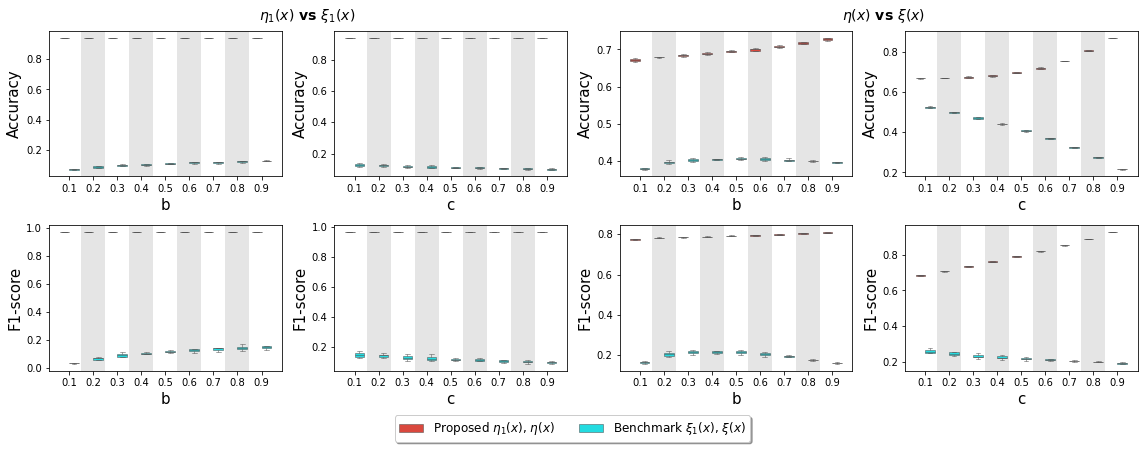

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 6))

a = 0.7
metrics_name_map = {'F-0.5': 'F-0.5 Score', 'F': 'F-1 Score', 'F-2': 'F-2 Score', 'ACC': 'Accuracy'}
palette = sns.color_palette('Paired')
# c1 = [palette[3], palette[2]]
# c2 = [palette[7], palette[6]]
cc = [lighten_color('#F8766D', amount=1.5), lighten_color('#00BFC4', amount=0.8)]
sns.boxplot(ax=axes[1][0], data=df[(df['a']==a) & (df['c']==0.5) & (df['model'].isin(['eta1', 'eta1_bench'])) & (df['metric']=='F')], x='b', y='value', hue='model', palette=cc, showfliers=False, linewidth=0.5)
sns.boxplot(ax=axes[1][1], data=df[(df['a']==a) & (df['b']==0.5) &(df['model'].isin(['eta1', 'eta1_bench'])) & (df['metric']=='F')], x='c', y='value', hue='model', palette=cc, showfliers=False, linewidth=0.5)
sns.boxplot(ax=axes[0][0], data=df[(df['a']==a) & (df['c']==0.5) &(df['model'].isin(['eta1', 'eta1_bench'])) & (df['metric']=='ACC')], x='b', y='value', hue='model', palette=cc, showfliers=False, linewidth=0.5)
sns.boxplot(ax=axes[0][1], data=df[(df['a']==a) & (df['b']==0.5) &(df['model'].isin(['eta1', 'eta1_bench'])) & (df['metric']=='ACC')], x='c', y='value', hue='model', palette=cc, showfliers=False, linewidth=0.5)
sns.boxplot(ax=axes[1][2], data=df[(df['a']==a) & (df['c']==0.5) &(df['model'].isin(['eta', 'eta_bench'])) & (df['metric']=='F')], x='b', y='value', hue='model', palette=cc, showfliers=False, linewidth=0.5)
sns.boxplot(ax=axes[1][3], data=df[(df['a']==a) & (df['b']==0.5) &(df['model'].isin(['eta', 'eta_bench'])) & (df['metric']=='F')], x='c', y='value', hue='model', palette=cc, showfliers=False, linewidth=0.5)
sns.boxplot(ax=axes[0][2], data=df[(df['a']==a) & (df['c']==0.5) &(df['model'].isin(['eta', 'eta_bench'])) & (df['metric']=='ACC')], x='b', y='value', hue='model', palette=cc, showfliers=False, linewidth=0.5)
sns.boxplot(ax=axes[0][3], data=df[(df['a']==a) & (df['b']==0.5) &(df['model'].isin(['eta', 'eta_bench'])) & (df['metric']=='ACC')], x='c', y='value', hue='model', palette=cc, showfliers=False, linewidth=0.5)
axes[1][0].set_ylabel('F1-score', fontsize=15)
axes[1][1].set_ylabel('F1-score', fontsize=15)
axes[1][2].set_ylabel('F1-score', fontsize=15)
axes[1][3].set_ylabel('F1-score', fontsize=15)
axes[0][0].set_ylabel('Accuracy', fontsize=15)
axes[0][1].set_ylabel('Accuracy',fontsize=15)
axes[0][2].set_ylabel('Accuracy',fontsize=15)
axes[0][3].set_ylabel('Accuracy',fontsize=15)
axes[0][0].set_xlabel(f'b', fontsize=15)
axes[0][1].set_xlabel(f'c',fontsize=15)
axes[1][0].set_xlabel(f'b', fontsize=15)
axes[1][1].set_xlabel(f'c',fontsize=15 )
axes[0][2].set_xlabel(f'b',fontsize=15)
axes[0][3].set_xlabel(f'c',fontsize=15)
axes[1][2].set_xlabel(f'b', fontsize=15)
axes[1][3].set_xlabel(f'c',fontsize=15)
# axes[0][0].set_ylim((0.35, 0.92))
# axes[0][1].set_ylim((0.35, 0.92))
# axes[0][2].set_ylim((0.35, 0.92))
# axes[0][3].set_ylim((0.35, 0.92))

# axes[1][0].set_ylim((0.15, 0.9))
# axes[1][1].set_ylim((0.15, 0.9))
# axes[1][2].set_ylim((0.15, 0.9))
# axes[1][3].set_ylim((0.15, 0.9))
for i in range(2):
    for j in range(4):
        axes[i][j].legend_.remove()
        for k in range(0, 8):
            if k % 2 == 1:
                axes[i][j].axvspan(k-.5, k+.5, facecolor='black', alpha=0.1)
handles, labels = axes[0][0].get_legend_handles_labels()
# handles2, labels2 = axes[0][3].get_legend_handles_labels()
# handles = handles1 + handles2
fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.07),
          fancybox=True, shadow=True, ncol=5, handles=handles, labels=[r'Proposed $\eta_1(x)$, $\eta(x)$',  r'Benchmark $\xi_1(x)$, $\xi(x)$'], fontsize=12)

fig.text(0.27, 0.92, r'$\eta_1(x)$ vs $\xi_1(x)$', ha='center', fontsize=14, weight='bold')
fig.text(0.77, 0.92, r'$\eta(x)$ vs $\xi(x)$', ha='center', fontsize=14, weight='bold')

# Optional: Adjust spacing
plt.subplots_adjust(top=0.90, hspace=0.4)
fig.tight_layout(rect=[0, 0, 1, 0.92]) 
# plt.tight_layout()
# plt.savefig(f'eta_a_{a}.svg', bbox_inches = 'tight', format='svg')
# plt.savefig(f'eta_a_{a}.pdf', bbox_inches = 'tight', format='pdf', dpi=500)
plt.savefig(f'eta1_eta_a_{a}_celeA.pdf', bbox_inches = 'tight', format='pdf', dpi=500)

In [12]:
df[(df['a']==a) & (df['c']==0.5) & (df['model'].isin(['eta0', 'eta0_bench'])) & (df['metric']=='F')].describe()

,a,b,c,seed,value
count,900.0,900.000000,900.0,900.000000,900.000000
mean,0.5,0.500000,0.5,4743.520000,0.089749
std,0.0,0.258342,0.0,2593.199746,0.102857
min,0.5,0.100000,0.5,342.000000,0.000000
25%,0.5,0.300000,0.5,2660.000000,0.005236
50%,0.5,0.500000,0.5,4598.000000,0.045083
75%,0.5,0.700000,0.5,6796.000000,0.141776
max,0.5,0.900000,0.5,9964.000000,0.425628


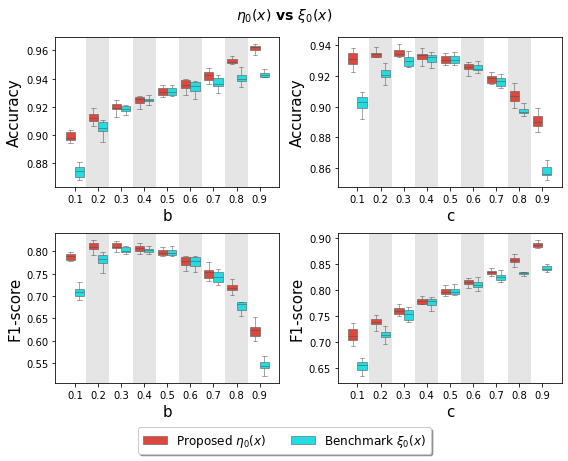

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 6))

a = 0.5
metrics_name_map = {'F-0.5': 'F-0.5 Score', 'F': 'F-1 Score', 'F-2': 'F-2 Score', 'ACC': 'Accuracy'}
palette = sns.color_palette('Paired')
cc = [lighten_color('#F8766D', amount=1.5), lighten_color('#00BFC4', amount=0.8)]
sns.boxplot(ax=axes[1][0], data=df[(df['a']==a) & (df['c']==0.5) & (df['model'].isin(['eta0', 'eta0_bench'])) & (df['metric']=='F')], x='b', y='value', hue='model', palette=cc, showfliers=False, linewidth=0.5)
sns.boxplot(ax=axes[1][1], data=df[(df['a']==a) & (df['b']==0.5) &(df['model'].isin(['eta0', 'eta0_bench'])) & (df['metric']=='F')], x='c', y='value', hue='model', palette=cc, showfliers=False, linewidth=0.5)
sns.boxplot(ax=axes[0][0], data=df[(df['a']==a) & (df['c']==0.5) &(df['model'].isin(['eta0', 'eta0_bench'])) & (df['metric']=='ACC')], x='b', y='value', hue='model', palette=cc, showfliers=False, linewidth=0.5)
sns.boxplot(ax=axes[0][1], data=df[(df['a']==a) & (df['b']==0.5) &(df['model'].isin(['eta0', 'eta0_bench'])) & (df['metric']=='ACC')], x='c', y='value', hue='model', palette=cc, showfliers=False, linewidth=0.5)

axes[1][0].set_ylabel('F1-score', fontsize=15)
axes[1][1].set_ylabel('F1-score', fontsize=15)
axes[0][0].set_ylabel('Accuracy', fontsize=15)
axes[0][1].set_ylabel('Accuracy',fontsize=15)
axes[1][0].set_xlabel(f'b', fontsize=15)
axes[1][1].set_xlabel(f'c',fontsize=15)
axes[0][0].set_xlabel(f'b', fontsize=15)
axes[0][1].set_xlabel(f'c',fontsize=15 )
# axes[0][0].set_ylim((0.8, 0.98))
# axes[0][1].set_ylim((0.8, 0.98))
# axes[0][0].set_yticks([0.8, 0.85, 0.9, 0.95,])
# axes[0][1].set_yticks([0.8, 0.85, 0.9, 0.95,])
# axes[1][0].set_ylim((0.35, 0.88))
# axes[1][1].set_ylim((0.35, 0.88))
for i in range(2):
    for j in range(2):
        axes[i][j].legend_.remove()
        for k in range(0, 8):
            if k % 2 == 1:
                axes[i][j].axvspan(k-.5, k+.5, facecolor='black', alpha=0.1)
handles, labels = axes[0][0].get_legend_handles_labels()

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.07),
          fancybox=True, shadow=True, ncol=5, handles=handles, labels=[r'Proposed $\eta_0(x)$',  r'Benchmark $\xi_0(x)$'], fontsize=12)
# fig.text(0.25, 0.95, 'Group 1: Columns 1 & 2', ha='center', fontsize=14, weight='bold')
# fig.text(0.75, 0.95, 'Group 2: Columns 3 & 4', ha='center', fontsize=14, weight='bold')
plt.suptitle(r'$\eta_0(x)$ vs $\xi_0(x)$', fontsize=14, weight='bold')
# Optional: Adjust spacing
# plt.subplots_adjust(top=0.90, hspace=0.4)
# fig.tight_layout(rect=[0, 0, 1, 0.92]) 
plt.tight_layout()
# plt.savefig(f'eta_a_{a}.svg', bbox_inches = 'tight', format='svg')
# plt.savefig(f'eta_a_{a}.pdf', bbox_inches = 'tight', format='pdf', dpi=500)
# plt.savefig(f'eta0_a_{a}_celeA.pdf', bbox_inches = 'tight', format='pdf', dpi=500)

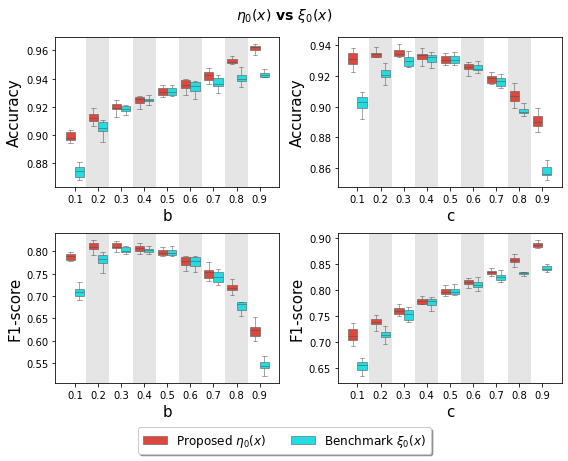

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 6))

a = 0.5
metrics_name_map = {'F-0.5': 'F-0.5 Score', 'F': 'F-1 Score', 'F-2': 'F-2 Score', 'ACC': 'Accuracy'}
palette = sns.color_palette('Paired')
cc = [lighten_color('#F8766D', amount=1.5), lighten_color('#00BFC4', amount=0.8)]
sns.boxplot(ax=axes[1][0], data=df[(df['a']==a) & (df['c']==0.5) & (df['model'].isin(['eta0', 'eta0_bench'])) & (df['metric']=='F')], x='b', y='value', hue='model', palette=cc, showfliers=False, linewidth=0.5)
sns.boxplot(ax=axes[1][1], data=df[(df['a']==a) & (df['b']==0.5) &(df['model'].isin(['eta0', 'eta0_bench'])) & (df['metric']=='F')], x='c', y='value', hue='model', palette=cc, showfliers=False, linewidth=0.5)
sns.boxplot(ax=axes[0][0], data=df[(df['a']==a) & (df['c']==0.5) &(df['model'].isin(['eta0', 'eta0_bench'])) & (df['metric']=='ACC')], x='b', y='value', hue='model', palette=cc, showfliers=False, linewidth=0.5)
sns.boxplot(ax=axes[0][1], data=df[(df['a']==a) & (df['b']==0.5) &(df['model'].isin(['eta0', 'eta0_bench'])) & (df['metric']=='ACC')], x='c', y='value', hue='model', palette=cc, showfliers=False, linewidth=0.5)

axes[1][0].set_ylabel('F1-score', fontsize=15)
axes[1][1].set_ylabel('F1-score', fontsize=15)
axes[0][0].set_ylabel('Accuracy', fontsize=15)
axes[0][1].set_ylabel('Accuracy',fontsize=15)
axes[1][0].set_xlabel(f'b', fontsize=15)
axes[1][1].set_xlabel(f'c',fontsize=15)
axes[0][0].set_xlabel(f'b', fontsize=15)
axes[0][1].set_xlabel(f'c',fontsize=15 )
# axes[0][0].set_ylim((0.8, 0.98))
# axes[0][1].set_ylim((0.8, 0.98))
# axes[0][0].set_yticks([0.8, 0.85, 0.9, 0.95,])
# axes[0][1].set_yticks([0.8, 0.85, 0.9, 0.95,])
# axes[1][0].set_ylim((0.35, 0.88))
# axes[1][1].set_ylim((0.35, 0.88))
for i in range(2):
    for j in range(2):
        axes[i][j].legend_.remove()
        for k in range(0, 8):
            if k % 2 == 1:
                axes[i][j].axvspan(k-.5, k+.5, facecolor='black', alpha=0.1)
handles, labels = axes[0][0].get_legend_handles_labels()

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.07),
          fancybox=True, shadow=True, ncol=5, handles=handles, labels=[r'Proposed $\eta_0(x)$',  r'Benchmark $\xi_0(x)$'], fontsize=12)
# fig.text(0.25, 0.95, 'Group 1: Columns 1 & 2', ha='center', fontsize=14, weight='bold')
# fig.text(0.75, 0.95, 'Group 2: Columns 3 & 4', ha='center', fontsize=14, weight='bold')
plt.suptitle(r'$\eta_0(x)$ vs $\xi_0(x)$', fontsize=14, weight='bold')
# Optional: Adjust spacing
# plt.subplots_adjust(top=0.90, hspace=0.4)
# fig.tight_layout(rect=[0, 0, 1, 0.92]) 
plt.tight_layout()
# plt.savefig(f'eta_a_{a}.svg', bbox_inches = 'tight', format='svg')
# plt.savefig(f'eta_a_{a}.pdf', bbox_inches = 'tight', format='pdf', dpi=500)
# plt.savefig(f'eta0_a_{a}_celeA.pdf', bbox_inches = 'tight', format='pdf', dpi=500)

In [11]:
import pickle
pkl_file = './experiment.pkl'
with open(pkl_file, 'rb') as f:
    data = pickle.load(f)

In [17]:
data['0.7_0.7_0.5_6352']['df'].groupby(['R','y', 'a']).count()

domain   cls
R y a              
0 0 0    3068  3068
    1     379   379
  1 0     379   379
    1    6136  6136
1 0 0    3068  3068
    1     883   883
  1 0     883   883